In [62]:
import pandas as pd
import numpy  as np
import plotly.express as px
import matplotlib.pyplot as plt


Usar Pandas para analisar onde estão ou se existem os erros/valores faltantes.

In [63]:
tabela = pd.read_csv("Iot_Network_data.csv")
tabela = (tabela.isnull().sum() / len(tabela)) * 100
display(tabela)

packet_size            0.0
transmission_time      0.0
protocol_type          0.0
bandwidth_usage        0.0
latency                0.0
jitter                 0.0
packet_loss_rate       0.0
device_id              0.0
device_type            0.0
energy_usage           0.0
allocated_bandwidth    0.0
dtype: float64

Não existem dados faltantes ↑

Excluindo algumas columns que eu considerava "não relevantes"↓↓↓↓

In [64]:
tabela = pd.read_csv("Iot_Network_data.csv")
tabela = tabela.drop(columns=["protocol_type", "device_type", "device_id"])
display(tabela.info())
display(tabela)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   packet_size          100000 non-null  int64  
 1   transmission_time    100000 non-null  float64
 2   bandwidth_usage      100000 non-null  float64
 3   latency              100000 non-null  float64
 4   jitter               100000 non-null  float64
 5   packet_loss_rate     100000 non-null  float64
 6   energy_usage         100000 non-null  float64
 7   allocated_bandwidth  100000 non-null  float64
dtypes: float64(7), int64(1)
memory usage: 6.1 MB


None

,packet_size,transmission_time,bandwidth_usage,latency,jitter,packet_loss_rate,energy_usage,allocated_bandwidth
0,1226,91.122098,15.623114,550.520270,1.955575,0.678984,3.070838,6.410492
1,960,33.345611,63.094117,222.891645,23.431288,0.432164,2.216078,34.671596
2,1394,18.012294,80.794838,86.795792,40.182257,0.377581,6.415588,82.953095
3,1230,95.410847,59.551855,925.876918,11.281608,1.057459,7.121031,28.562144
4,1195,34.216522,38.698202,427.947049,9.526643,3.684529,5.806726,96.234900
...,...,...,...,...,...,...,...,...
99995,280,73.263240,23.782773,645.344457,91.545641,1.508445,6.729374,11.965165
99996,959,35.752750,61.953559,247.885867,68.179297,2.253795,2.270973,42.556910
99997,263,1.936327,85.248796,633.860270,44.854565,1.247975,9.784983,1.896206
99998,389,97.668208,68.616472,984.933178,58.879209,2.656816,8.886877,86.431252


Preparando a Base de dados que a IA vai usar

In [65]:
from sklearn.preprocessing import LabelEncoder
cod_packet_size = LabelEncoder()
tabela["packet_size"] = cod_packet_size.fit_transform(tabela["packet_size"])
cod_transmission_time = LabelEncoder()
tabela["transmission_time"] = cod_transmission_time.fit_transform(tabela["transmission_time"])
cod_latency = LabelEncoder()
tabela["latency"] = cod_latency.fit_transform(tabela["latency"])
cod_jitter = LabelEncoder()
tabela["jitter"] = cod_jitter.fit_transform(tabela["jitter"])
display(tabela.info())


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   packet_size          100000 non-null  int64  
 1   transmission_time    100000 non-null  int64  
 2   bandwidth_usage      100000 non-null  float64
 3   latency              100000 non-null  int64  
 4   jitter               100000 non-null  int64  
 5   packet_loss_rate     100000 non-null  float64
 6   energy_usage         100000 non-null  float64
 7   allocated_bandwidth  100000 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 6.1 MB


None

Determinando qual Columns é o objetivo de previsão (bandwidth_usage)

In [66]:
y = tabela["bandwidth_usage"]
x = tabela.drop(columns=["bandwidth_usage"])
from sklearn.model_selection import train_test_split
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.3, random_state=42)

In [67]:
from sklearn.preprocessing import StandardScaler

escala = StandardScaler()

X_treino_escala = escala.fit_transform(x_treino)
X_teste_escala = escala.transform(x_teste)

Usando o Fit para treinar a IA usando as 4 columns

In [68]:
from sklearn.ensemble import RandomForestRegressor

ia_forest = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

ia_forest.fit(x_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Colocando a IA sobre o teste para avaliar se Bandwidth Usage se relaciona com alguma das columns

In [69]:
prev_forest = ia_forest.predict(x_teste)
from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_teste, prev_forest))
r2 = r2_score(y_teste, prev_forest)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 29.14452128650474
R²: -0.019871271389829692


Plotando os resultados previsto x real adquiridos pela IA

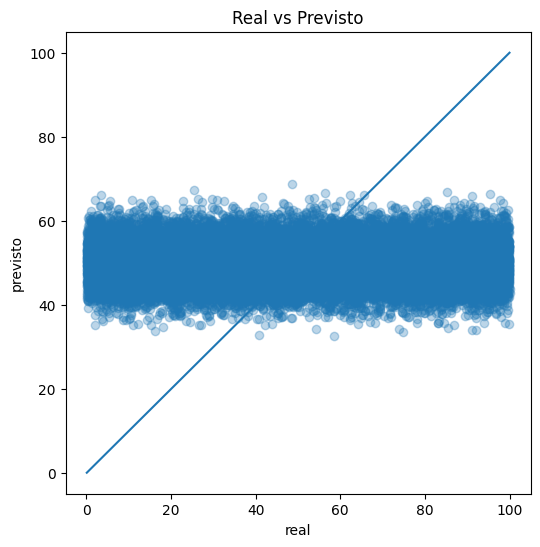

In [70]:
plt.figure(figsize=(6,6))
plt.scatter(y_teste, prev_forest, alpha=0.3)
plt.plot([y_teste.min(), y_teste.max()], [y_teste.min(), y_teste.max()],)
plt.xlabel("real")
plt.ylabel("previsto")
plt.title("Real vs Previsto")

plt.show()

Conclusão: Ou os dados utilizados não influenciam na Bandwidth Usage ou as columns que foram excluidas eram essenciais. Voltar futuramente para ajustar e procurar relações essenciais. (2026)